<a href="https://colab.research.google.com/github/hamedtavakoli/MyColab/blob/main/SSL_SOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# Setup: Earth Engine + SOM tools
# ============================
!pip -q install earthengine-api geemap minisom xarray netCDF4 pandas numpy matplotlib

import ee, geemap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from minisom import MiniSom

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.4 MB/s eta 0:00:00


In [ ]:
ee.Authenticate()
ee.Initialize(project="gcmcluster")  # Replace with your actual Google Cloud Project ID

In [ ]:
# ============================
# User settings
# ============================
# Use 'daily' or 'monthly' anomalies; start with monthly for speed
MODE = 'monthly'  # 'daily' or 'monthly'
START = '1982-01-01'
END   = '2002-12-31'

In [ ]:
# Spatial resolution for SOM input (coarsen to reduce dimensionality)
# 4 degrees ≈ ~100x90 ocean cells -> ~9k features per sample; adjust as you like
TARGET_DEG = 4.0

import numpy as np
import ee, geemap

def make_vector_grid(step_deg=4.0):
    """FeatureCollection of rectangular cells covering the globe, with i (lon idx) and j (lat idx)."""
    lons = np.arange(-180, 180, step_deg)
    lats = np.arange( -90,  90, step_deg)
    feats = []
    for i, lon in enumerate(lons):
        for j, lat in enumerate(lats):
            geom = ee.Geometry.Rectangle([lon, lat, lon+step_deg, lat+step_deg], geodesic=False)
            feats.append(ee.Feature(geom, {'i': i, 'j': j}))
    return ee.FeatureCollection(feats)

# one-time grid (uses your TARGET_DEG)
GRID_FC = make_vector_grid(TARGET_DEG)


# Ice mask threshold (percent)
ICE_THRESH = 15.0

# SOM map size (grid of nodes) and training iters
SOM_X, SOM_Y = 4, 3         # 12 prototype patterns
SOM_ITERS    = 5000         # increase later for stability

In [ ]:
# ============================
# Helpers: grids, regridding
# ============================
def make_global_grid(step_deg=4.0):
    """Return an ee.Image with two bands: 'lon_idx','lat_idx' tiling the globe in step_deg."""
    lonlat = ee.Image.pixelLonLat()
    lon_idx = lonlat.select('longitude').add(180).divide(step_deg).floor().toInt16()
    lat_idx = lonlat.select('latitude') .add( 90).divide(step_deg).floor().toInt16()
    return lon_idx.rename('lon_idx').addBands(lat_idx.rename('lat_idx'))

def regrid_mean(img, grid_fc, band='anom'):
    """
    img: ee.Image with a single band named `band` (e.g., 'anom')
    returns: pandas DataFrame with columns i, j, mean
    """
    img1 = img.select([band])  # enforce a single band by name
    red  = img1.reduceRegions(
        collection = grid_fc,
        reducer    = ee.Reducer.mean(),
        scale      = 25000,    # fine for OISST 0.25°
    )
    # Convert ee.FeatureCollection to pandas DataFrame manually
    features = red.getInfo()['features']
    data = []
    for f in features:
        props = f['properties']
        if 'mean' in props:
            data.append({'i': props['i'], 'j': props['j'], 'mean': props['mean']})
        elif band in props:
            data.append({'i': props['i'], 'j': props['j'], 'mean': props[band]})

    df = pd.DataFrame(data)

    return df[['i','j','mean']]

In [ ]:
# ============================
# Build daily/monthly anomalies from OISST
# ============================
OISST = ee.ImageCollection('NOAA/CDR/OISST/V2_1')

def daily_image(date_str):
    ic = OISST.filterDate(date_str, ee.Date(date_str).advance(1,'day'))
    img = ee.Image(ic.first())
    # Scale
    sstC   = img.select('sst').multiply(0.01).rename('sst_c')
    icePct = img.select('ice').unmask(0, False).multiply(0.01).rename('ice_pct')
    ocean_mask = sstC.gt(-2).And(sstC.lt(45)).And(icePct.lte(ICE_THRESH))
    return sstC.updateMask(ocean_mask)

def monthly_mean_image(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end   = start.advance(1, 'month')
    ic = OISST.filterDate(start, end)
    mean = ic.mean()
    sstC   = mean.select('sst').multiply(0.01).rename('sst_c')
    icePct = mean.select('ice').unmask(0, False).multiply(1).rename('ice_pct')
    ocean_mask = sstC.gt(-2).And(sstC.lt(45)).And(icePct.lte(ICE_THRESH))
    return sstC.updateMask(ocean_mask)

def clim_month_1982_2011(month):
    clim = (OISST
            .filterDate('1982-01-01', ee.Date('2011-12-31').advance(1,'day'))
            .filter(ee.Filter.calendarRange(month, month, 'month'))
            .select('sst').mean()
           ).multiply(0.01).rename('sst_c_clim')
    return clim

def anomaly_image(date_str, mode='monthly'):
    d = ee.Date(date_str)
    if mode == 'daily':
        sst = daily_image(date_str)
        clim = clim_month_1982_2011(d.get('month'))
    else:
        y = d.get('year').getInfo(); m = d.get('month').getInfo()
        sst = monthly_mean_image(y, m)
        clim = clim_month_1982_2011(m)
    anom = sst.subtract(clim).rename('anom')  # IMPORTANT: name = 'anom'
    # keep the same mask as SST (already sea-ice filtered in your daily/monthly funcs)
    return anom.updateMask(sst.mask())


In [ ]:
# ============================
# Build a time stack of anomaly fields (coarse grid)
# ============================
grid = make_global_grid(TARGET_DEG)

# Build date list
if MODE == 'monthly':
    dates = pd.date_range(START, END, freq='MS')
else:
    dates = pd.date_range(START, END, freq='D')

stack_list = []
meta_dates = []
for d in dates:
    try:
        anom = anomaly_image(d.strftime('%Y-%m-%d'), mode=MODE)  # ee.Image (masked)

        # Check if 'anom' is valid (not Python None).
        if anom is None:
            print(f"Skip {d}: anomaly_image returned None, indicating no valid image data.")
            continue

        # Regrid to coarse grid via per-cell mean using vector grid:
        tbl = regrid_mean(anom, GRID_FC)   # pandas DataFrame: columns ['i','j','mean']
        # Create a 2D array (lat x lon). We stored i=lon idx, j=lat idx.
        if tbl.empty:
            print(f"Skip {d}: Regridded table is empty for {d}.")
            continue

        # Fixed grid shape from TARGET_DEG
        step = float(TARGET_DEG)
        lon_edges = np.arange(-180, 180, step)
        lat_edges = np.arange( -90,  90, step)
        n_lon = len(lon_edges)
        n_lat = len(lat_edges)

        arr = np.full((n_lat, n_lon), np.nan, dtype='float32')
        sub = tbl.dropna()
        sub = sub[(sub['i']>=0)&(sub['i']<n_lon)&(sub['j']>=0)&(sub['j']<n_lat)]

        for _, r in sub.iterrows():
            arr[int(r['j']), int(r['i'])] = float(r['mean'])

        stack_list.append(arr)
        meta_dates.append(d)

    except Exception as e:
        print('Skip', d, e)

if len(stack_list) == 0:
    raise RuntimeError('No frames were built; check date range, MODE, or masks.')

stack = np.stack(stack_list, axis=0)   # shape: (T, n_lat, n_lon)
print('Stack shape:', stack.shape)

# Replace NaNs (SOM needs finite inputs)
stack[np.isnan(stack)] = 0.0

n_times, n_lat, n_lon = stack.shape
vectors = stack.reshape(n_times, n_lat*n_lon).astype('float32')
print('Vectors shape:', vectors.shape)

Stack shape: (252, 45, 90)
Vectors shape: (252, 4050)


In [ ]:
# ============================
# Train SOM on anomaly vectors
# ============================
som = MiniSom(SOM_X, SOM_Y, vectors.shape[1], sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.random_weights_init(vectors)
som.train_random(vectors, SOM_ITERS)

# BMU (best matching unit) for each date
bmus = [som.winner(v) for v in vectors]         # list of (x,y)
bmu_ids = np.array([x* SOM_Y + y for (x,y) in bmus])  # flatten 2D index to 0..(SOM_X*SOM_Y-1)

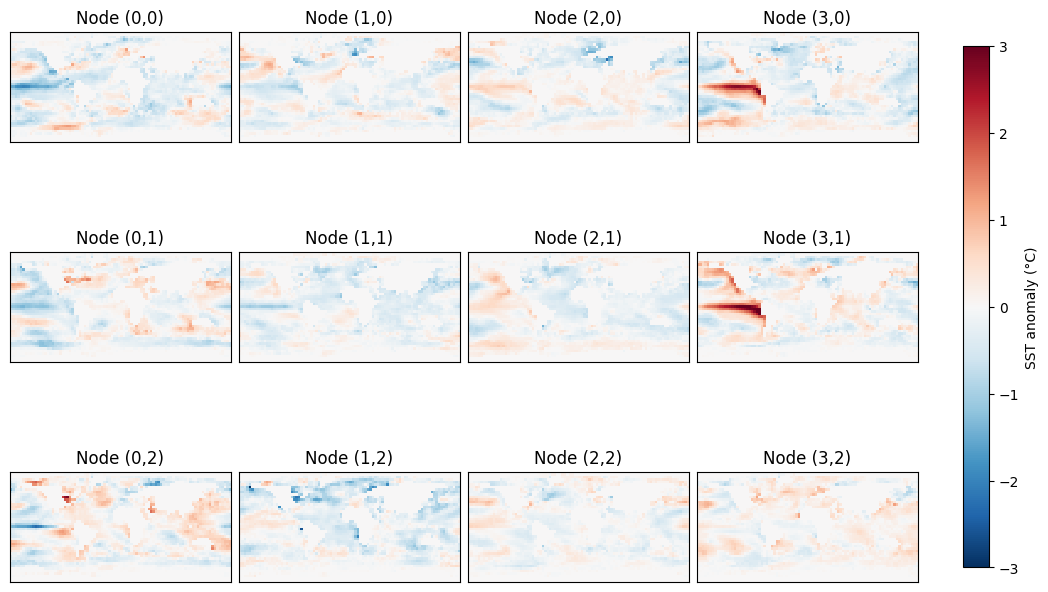

In [ ]:
# ============================
# Visualize: SOM prototypes as 2-D maps
# ============================
fig, axes = plt.subplots(SOM_Y, SOM_X, figsize=(2.6*SOM_X, 2.2*SOM_Y), constrained_layout=True)
for x in range(SOM_X):
    for y in range(SOM_Y):
        w = som.get_weights()[x, y].reshape(n_lat, n_lon)
        ax = axes[y, x] if SOM_Y>1 else axes[x]
        im = ax.imshow(w[::-1, :], cmap='RdBu_r', vmin=-3, vmax=3, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'Node ({x},{y})')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='SST anomaly (°C)')
plt.show()


In [ ]:
# ============================
# Time series of node occupancy
# ============================
occ = pd.Series(bmu_ids).value_counts().sort_index()
print('Node occupancy counts:\n', occ)

ts = pd.DataFrame({'date': meta_dates, 'node_id': bmu_ids})
display(ts)

# (Optional) Save outputs (CSV)
ts.to_csv('som_bmu_timeseries.csv', index=False)

Node occupancy counts:
 0     13
1     20
2      8
3     20
4     40
5     13
6     22
7     38
8     28
9     12
10    12
11    26
Name: count, dtype: int64


,date,node_id
0,1982-01-01,4
1,1982-02-01,5
2,1982-03-01,5
3,1982-04-01,5
4,1982-05-01,5
...,...,...
247,2002-08-01,11
248,2002-09-01,11
249,2002-10-01,11
250,2002-11-01,6


from matplotlib import pyplot as plt
ts['node_id'].plot(kind='hist', bins=20, title='node_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['node_id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ts.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('node_id')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date'}, axis=1)
              .sort_values('date', ascending=True))
  xs = counted['date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ts.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['node_id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ts.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('node_id')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date'}, axis=1)
              .sort_values('date', ascending=True))
  xs = counted['date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ts.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
ts['node_id'].plot(kind='line', figsize=(8, 4), title='node_id')
plt.gca().spines[['top', 'right']].set_visible(False)

NameError: name 'ts' is not defined

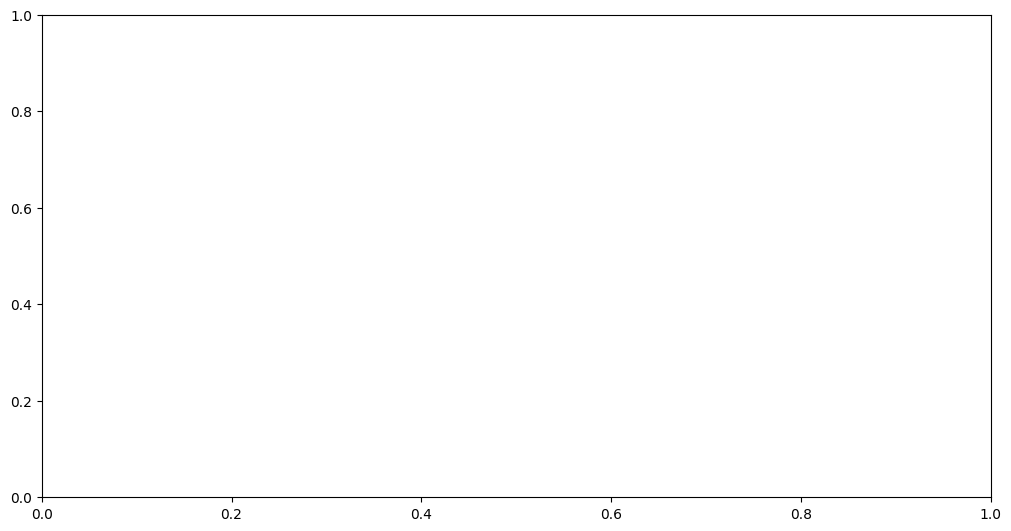

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date']
  ys = series['node_id']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ts.sort_values('date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('node_id')